In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim 

In [68]:
df = pd.read_csv('../datasets/WineQT.csv')

In [69]:
df.shape

(1143, 13)

In [70]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [71]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [72]:
skew_cpy = df.select_dtypes(include='number').copy()
skew_cpy.skew()

fixed acidity           1.044930
volatile acidity        0.681547
citric acid             0.371561
residual sugar          4.361096
chlorides               6.026360
free sulfur dioxide     1.231261
total sulfur dioxide    1.665766
density                 0.102395
pH                      0.221138
sulphates               2.497266
alcohol                 0.863313
quality                 0.286792
Id                     -0.010419
dtype: float64

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [74]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [75]:
df_dup = df[df.duplicated()]

In [76]:
df.drop('Id', axis=1, inplace=True)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [77]:
# Rename the columns

def transform_col(col: str) -> str:
    col = col.lower()
    words = col.split(' ')
    
    if len(words) == 1:
        return words[0]

    word = '_'.join(words)

    return word 

df.columns = [transform_col(col) for col in df.columns]

df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [78]:
from matplotlib.colors import TABLEAU_COLORS

tab_colors = list(TABLEAU_COLORS.values())

print(tab_colors)

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


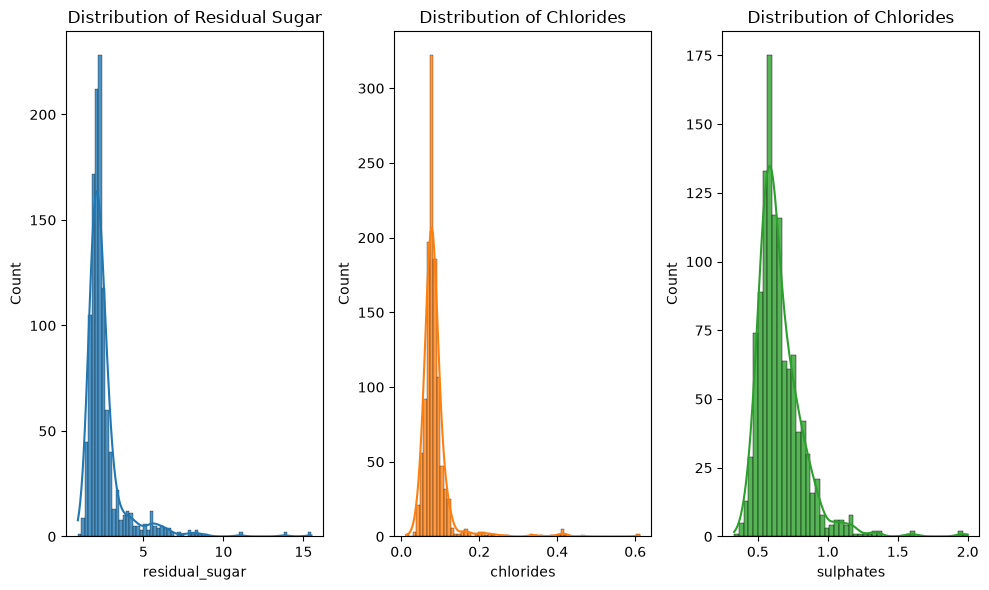

In [79]:
fig, ax = plt.subplots(1, 3, figsize=(10, 6))

sns.histplot(data=df, x='residual_sugar', color=tab_colors[0], kde=True, alpha=0.8, ax=ax[0])
ax[0].set_title('Distribution of Residual Sugar')

sns.histplot(data=df, x='chlorides', color=tab_colors[1], kde=True, alpha=0.8, ax=ax[1])
ax[1].set_title('Distribution of Chlorides')

sns.histplot(data=df, x='sulphates', color=tab_colors[2], kde=True, alpha=0.8, ax=ax[2])
ax[2].set_title('Distribution of Chlorides') 

plt.tight_layout()
plt.show()

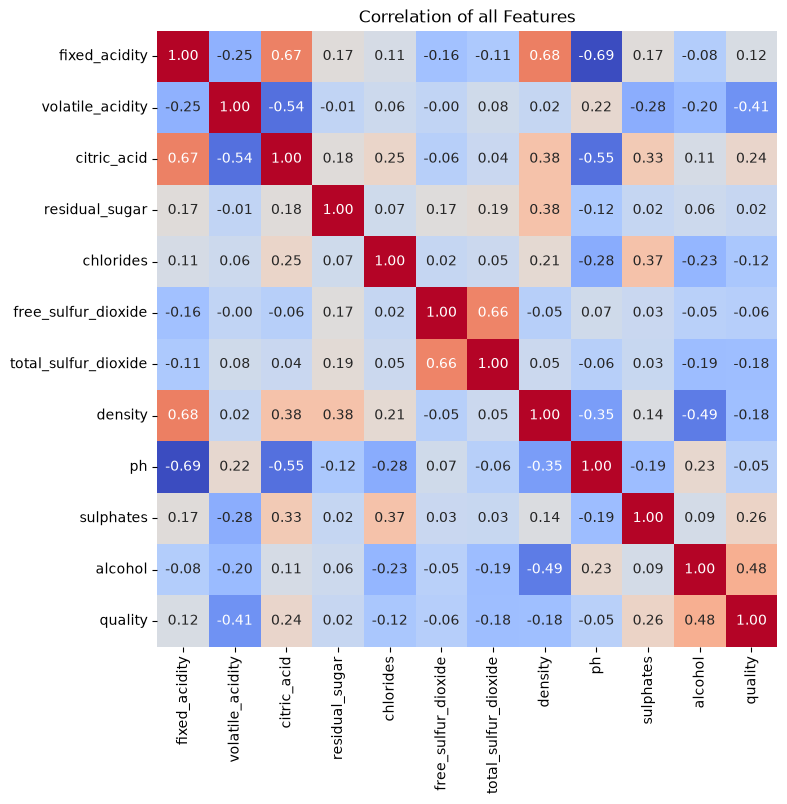

In [80]:
# Plot a heatmap of all the features (all features are numerical)

_corr = df.corr()

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.heatmap(data=_corr, annot=True, fmt='.2f', cbar=False, cmap='coolwarm', ax=ax)
ax.set_title('Correlation of all Features')
plt.show()

In [81]:
# Make a copy where skew is removed 

dfs = df.copy()

dfs['residual_sugar'] = dfs['residual_sugar'].transform('log1p')
dfs['chlorides'] = dfs['chlorides'].transform('log1p')

dfs.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.064711,0.073250,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,1.280934,0.093490,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,1.193922,0.088011,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.064711,0.072321,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.064711,0.073250,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [82]:
# Extract target and data

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [83]:
classes = np.unique(y)   
y_encoded = np.searchsorted(classes, y)

In [84]:
# Split into training and testing data 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [85]:
# Split for the random forest

_, _, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
# Scale the dataset

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [87]:
# Find the number of unique values

class_num = len(np.unique(y))
class_num

6

In [88]:
# Construct the ANN

class WineClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(X.shape[1], 64)
        self.fc2 = nn.Linear(64, 16)
        self.fc3 = nn.Linear(16, class_num)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [89]:
# Define the model

model = WineClassifier()

In [90]:
# Define the loss and optiimzer

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [91]:
# Set up the data

X_train_tensor = torch.from_numpy(X_train_scaled).float()
X_test_tensor = torch.from_numpy(X_test_scaled).float()

y_train_tensor = torch.from_numpy(y_train).long()
y_test_tensor = torch.from_numpy(y_test).long()

In [92]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [93]:
# See the data types of model and train_loader

print(type(model), type(train_loader))

<class '__main__.WineClassifier'> <class 'torch.utils.data.dataloader.DataLoader'>


In [94]:
# Train the model

def training_loop(model: WineClassifier, data: DataLoader, epochs: int):
    for _ in range(epochs):
        model.train()

        for x_batch, y_batch in data:
            optimizer.zero_grad()

            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)

            loss.backward()
            optimizer.step()

In [95]:
# Make predictions on test data

model.eval()

with torch.no_grad():
    y_pred = model(X_test_tensor)

y_pred_np = y_pred.numpy()

y_pred_np = np.argmax(y_pred_np, axis=1)

y_pred_labels = classes[y_pred_np] 

In [96]:
# Save results to a confusion matrix
from sklearn.metrics import confusion_matrix

ann_cm = confusion_matrix(y_test, y_pred_labels)

In [97]:
# Define a random forest model

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

In [98]:
# Tune the hyperparamters a bit

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train_rf)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.6498108448928122


In [99]:
# Train the random forest and get a prediction (does not need to be scaled)

best_rf.fit(X_train, y_train_rf)
y_pred_rf = best_rf.predict(X_test)

In [100]:
# Save the results to a confusion matrix

rf_cm = confusion_matrix(y_test_rf, y_pred_rf)

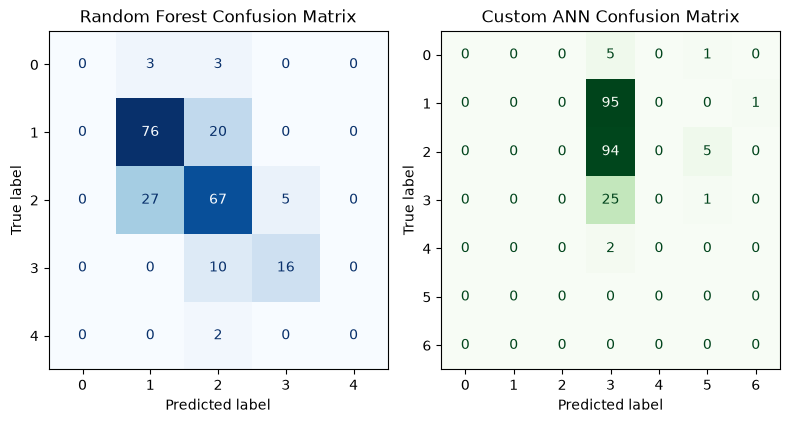

In [101]:
# Display both in the subplots

from sklearn.metrics import ConfusionMatrixDisplay

rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm)
ann_disp = ConfusionMatrixDisplay(confusion_matrix=ann_cm)

fig, ax = plt.subplots(1, 2, figsize=(8, 8))

rf_disp.plot(cmap="Blues", colorbar=False, ax=ax[0])
ax[0].set_title("Random Forest Confusion Matrix")

ann_disp.plot(cmap="Greens", colorbar=False, ax=ax[1])
ax[1].set_title("Custom ANN Confusion Matrix")

plt.tight_layout()
plt.show()